# 키워드 일반성 분석 — 고성공키워드는 '흔한' 키워드인가?

> **소목적**: M1·M2 파생변수(고성공/고실패 키워드 · 키워드 일반성)를 더 파고들어 — *고성공키워드가 상품에 일반적으로(흔하게) 등장하는 키워드인지, 아니면 희귀·특이한 키워드인지*를 규명.
> **상위목적(유지)**: 모델 v2_sweepA가 성공/실패 패턴을 **어떤 키워드에서** 학습했고, 그것이 **FN·FP 오분류**에 어떻게 작용하는가.
> **데이터**: train+val 라벨만(test 누수 차단). 키워드 성공률·일반성은 `network_eda` M0-d 장부 로직 재사용.

In [1]:
# [0] 환경 · 데이터 · 키워드 장부 (train+val only)
import sys, warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, yaml
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
ROOT=Path.cwd()
while not (ROOT/'src'/'models'/'hin_gnn.py').exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
sys.path.insert(0,str(ROOT))
try: plt.rcParams['font.family']='Malgun Gothic'
except Exception: pass
plt.rcParams['axes.unicode_minus']=False
SHARE=ROOT/'7eleven_npd_share'/'data'/'processed'/'hin'; EXP=ROOT/'experiments'/'results'/'v2_sweepA'
NBDIR=ROOT/'eda'/'network_eda_원준'; ASSETS=NBDIR/'report_assets'; ASSETS.mkdir(parents=True,exist_ok=True)
def savefig(fig,name): fig.savefig(ASSETS/name,dpi=120,bbox_inches='tight')
from src.data_builder.build_hetero_data import build_graph, norm_id
CFG=yaml.safe_load(open(EXP/'config_used.yaml',encoding='utf-8')); g=CFG['graph']
data,maps=build_graph(data_dir=str(SHARE),ratios=tuple(CFG['split']['ratios']),seed=CFG['split']['seed'],
  include_offline_copurchase=False,include_quick_copurchase=False,
  add_2hop_edges=g.get('add_2hop_edges',True),hop2_kw_min_shared=g.get('hop2_kw_min_shared',3),hop2_ip_min_shared=g.get('hop2_ip_min_shared',1),
  add_via_ip_edges=g.get('add_via_ip_edges',True),add_ipip_kw_edges=g.get('add_ipip_kw_edges',True),add_trend_kw_edges=g.get('add_trend_kw_edges',True))
P=len(maps['product_ids'])
y_np=data['product'].y.cpu().numpy().astype(int)
tr=data['product'].train_mask.cpu().numpy(); va=data['product'].val_mask.cpu().numpy(); te=data['product'].test_mask.cpu().numpy(); tv=tr|va
pids=np.array([str(x) for x in maps['product_ids']])
tv_pids=set(pids[tv])
ydf=pd.Series(y_np,index=pids)
pk=pd.read_parquet(SHARE/'product_keyword_edges_final.parquet'); pk['pid']=pk['ITEM_CD'].map(norm_id); pk['keyword']=pk['keyword'].astype(str)
pk_tv=pk[pk['pid'].isin(tv_pids)].copy(); pk_tv['y']=pk_tv['pid'].map(ydf)
ks=pk_tv.groupby('keyword')['y'].agg(['mean','count']); MIN=5; ko=ks[ks['count']>=MIN].copy()
hi,lo=ko['mean'].quantile(0.95),ko['mean'].quantile(0.05)
kw_succ=set(ko[ko['mean']>=hi].index); kw_fail=set(ko[ko['mean']<=lo].index)
kw_pop=pk[pk['pid'].isin(tv_pids)].groupby('keyword')['pid'].nunique()
ko['pop']=ko.index.map(kw_pop).astype(float)
base=float(y_np[tv].mean())
n_prod_all=int(pk['pid'].nunique())
n_prod_succ=int(pk[pk['keyword'].isin(kw_succ)]['pid'].nunique())
n_prod_fail=int(pk[pk['keyword'].isin(kw_fail)]['pid'].nunique())
import os as _os
ipset=set()
for _f in ['ip_nodes_final.parquet','product_ip_edges_final.parquet']:
    if _os.path.exists(SHARE/_f): ipset|=set(pd.read_parquet(SHARE/_f)['ip_name'].astype(str))
ip_in_succ=sorted(kw_succ & ipset); ip_in_fail=sorted(kw_fail & ipset)
ex_s=ko.loc[sorted(kw_succ)].sort_values(['mean','pop'],ascending=[False,False]).head(20)
ex_f=ko.loc[sorted(kw_fail)].sort_values('pop',ascending=False).head(20)
print(f'[상품 수] 고성공 키워드 보유 {n_prod_succ} / 고실패 보유 {n_prod_fail} / 키워드보유 전체 {n_prod_all}')
print('[고성공 20 (성공률/보유상품수)] '+', '.join(f"{k}({r['mean']:.2f}/{int(r['pop'])})" for k,r in ex_s.iterrows()))
print('[고실패 20 (성공률/보유상품수)] '+', '.join(f"{k}({r['mean']:.2f}/{int(r['pop'])})" for k,r in ex_f.iterrows()))
print(f'[IP 겹침] 고성공∩IP={ip_in_succ} / 고실패∩IP={ip_in_fail}')
print(f'키워드(전체) {len(ks)} / 분석대상(등장상품수>={MIN}) {len(ko)} | 고성공 {len(kw_succ)}(>= {hi:.2f}) / 고실패 {len(kw_fail)}(<= {lo:.2f}) | 기저성공률 {base:.3f}')
sp=spearmanr(ko['pop'],ko['mean']).correlation; pr=pearsonr(np.log10(ko['pop']),ko['mean'])[0]
print(f'성공률 vs 일반성: Spearman(pop,성공률)={sp:.3f} / Pearson(log10pop,성공률)={pr:.3f}')
med_all=float(ko["pop"].median()); med_s=float(ko.loc[sorted(kw_succ),"pop"].median()); med_f=float(ko.loc[sorted(kw_fail),"pop"].median())
print(f'등장상품수 중앙값 — 전체 {med_all:.0f} / 고성공 {med_s:.0f} / 고실패 {med_f:.0f}')

[상품 수] 고성공 키워드 보유 340 / 고실패 보유 834 / 키워드보유 전체 5032
[고성공 20 (성공률/보유상품수)] 관람(1.00/5), 로코모코(1.00/5), 알포트(0.83/6), 하와이(0.80/10), 고창(0.80/5), 레드벨벳(0.80/5), 맥스봉(0.80/5), 띠부씰(0.73/15), 커스터드(0.71/14), 녹진함(0.67/6), 데이지(0.67/6), 미각(0.67/6), 미역(0.67/6), 발효(0.67/6), 에일(0.67/6), 타우린(0.67/6), 트로피컬(0.67/6), 프링글스(0.67/6), 홈런(0.67/6), 후르츠(0.65/17)
[고실패 20 (성공률/보유상품수)] 캔(0.00/31), 다리(0.00/22), 찌개(0.00/21), 소다(0.00/16), 블렌디드(0.00/16), 하림(0.00/15), 빅(0.00/14), 곰(0.00/14), 식빵(0.00/14), 조니워커(0.00/13), 페어링(0.00/13), 모카(0.00/12), 하인즈(0.00/12), 주먹밥(0.00/12), 복날(0.00/12), 한우(0.00/12), 맥시칸(0.00/11), 모스카토(0.00/11), 해장(0.00/11), 짐빔(0.00/11)
[IP 겹침] 고성공∩IP=[] / 고실패∩IP=[]
키워드(전체) 1848 / 분석대상(등장상품수>=5) 719 | 고성공 37(>= 0.58) / 고실패 99(<= 0.00) | 기저성공률 0.238
성공률 vs 일반성: Spearman(pop,성공률)=0.097 / Pearson(log10pop,성공률)=0.065
등장상품수 중앙값 — 전체 13 / 고성공 6 / 고실패 7


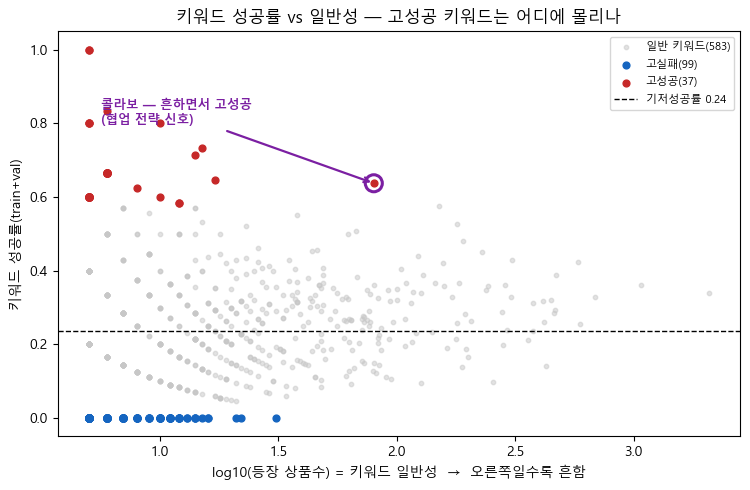

In [2]:
# [A·B] 산점도: 키워드 성공률 vs 일반성 (고성공/고실패 강조)
gen=[k for k in ko.index if k not in kw_succ and k not in kw_fail]
fig,ax=plt.subplots(figsize=(7.6,5))
ax.scatter(np.log10(ko.loc[gen,'pop']),ko.loc[gen,'mean'],s=10,c='#c7c7c7',alpha=.5,label=f'일반 키워드({len(gen)})')
ax.scatter(np.log10(ko.loc[sorted(kw_fail),'pop']),ko.loc[sorted(kw_fail),'mean'],s=24,c='#1565c0',label=f'고실패({len(kw_fail)})')
ax.scatter(np.log10(ko.loc[sorted(kw_succ),'pop']),ko.loc[sorted(kw_succ),'mean'],s=24,c='#c62828',label=f'고성공({len(kw_succ)})')
ax.axhline(base,ls='--',c='k',lw=1,label=f'기저성공률 {base:.2f}')
ax.set_xlabel('log10(등장 상품수) = 키워드 일반성  →  오른쪽일수록 흔함'); ax.set_ylabel('키워드 성공률(train+val)')
ax.legend(fontsize=8,loc='upper right'); ax.set_title('키워드 성공률 vs 일반성 — 고성공 키워드는 어디에 몰리나')
if '콜라보' in ko.index:
    _cx=float(np.log10(ko.loc['콜라보','pop'])); _cy=float(ko.loc['콜라보','mean'])
    ax.scatter([_cx],[_cy],s=150,facecolors='none',edgecolors='#7b1fa2',linewidths=2.2,zorder=6)
    ax.annotate('콜라보 — 흔하면서 고성공\n(협업 전략 신호)',xy=(_cx,_cy),xytext=(_cx-1.15,_cy+0.16),
                fontsize=9,color='#7b1fa2',fontweight='bold',ha='left',
                arrowprops=dict(arrowstyle='->',color='#7b1fa2',lw=1.6))
plt.tight_layout(); savefig(fig,'kwgen_scatter.png'); plt.show()

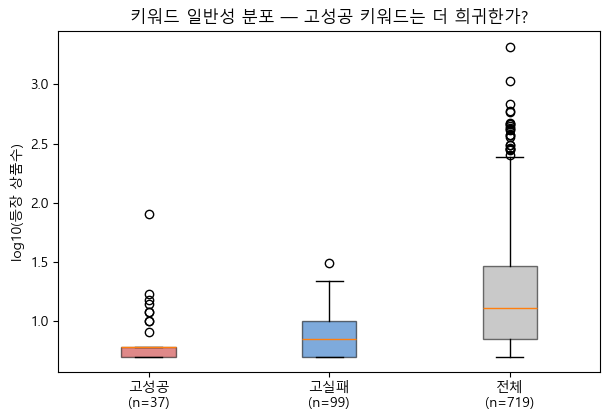

In [3]:
# [C] 일반성 분포 비교: 고성공 vs 고실패 vs 전체
fig,ax=plt.subplots(figsize=(6.2,4.3))
bp=ax.boxplot([np.log10(ko.loc[sorted(kw_succ),'pop']),np.log10(ko.loc[sorted(kw_fail),'pop']),np.log10(ko['pop'])],
   labels=[f'고성공\n(n={len(kw_succ)})',f'고실패\n(n={len(kw_fail)})',f'전체\n(n={len(ko)})'],patch_artist=True)
for b,c in zip(bp['boxes'],['#c62828','#1565c0','#9e9e9e']): b.set_facecolor(c); b.set_alpha(.55)
ax.set_ylabel('log10(등장 상품수)'); ax.set_title('키워드 일반성 분포 — 고성공 키워드는 더 희귀한가?')
plt.tight_layout(); savefig(fig,'kwgen_box.png'); plt.show()

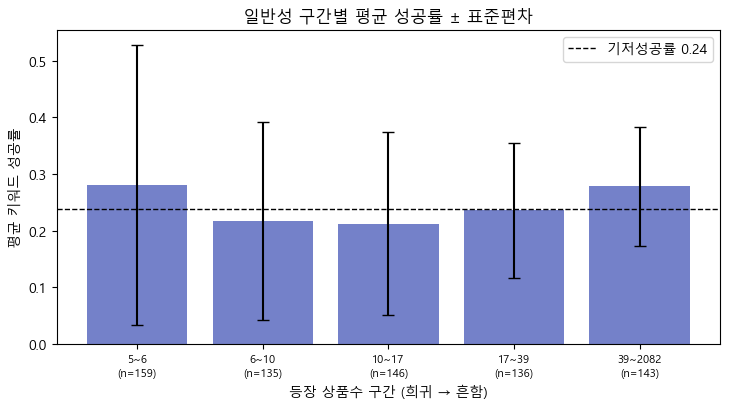

희귀구간 평균성공률 0.281(std 0.247) → 흔한구간 0.278(std 0.106)


In [4]:
# [D] 일반성 구간별 평균 성공률 (흔할수록 기저로 수렴?)
ko['popbin']=pd.qcut(ko['pop'],5,duplicates='drop')
b=ko.groupby('popbin',observed=True)['mean'].agg(['mean','std','count'])
fig,ax=plt.subplots(figsize=(7.4,4.2))
ax.bar(range(len(b)),b['mean'],yerr=b['std'],capsize=4,color='#5c6bc0',alpha=.85)
ax.axhline(base,ls='--',c='k',lw=1,label=f'기저성공률 {base:.2f}')
ax.set_xticks(range(len(b))); ax.set_xticklabels([f'{iv.left:.0f}~{iv.right:.0f}\n(n={c})' for iv,c in zip(b.index,b['count'])],fontsize=8)
ax.set_xlabel('등장 상품수 구간 (희귀 → 흔함)'); ax.set_ylabel('평균 키워드 성공률'); ax.legend()
ax.set_title('일반성 구간별 평균 성공률 ± 표준편차'); plt.tight_layout(); savefig(fig,'kwgen_bin.png'); plt.show()
binmin=float(b['mean'].iloc[0]); binmax=float(b['mean'].iloc[-1]); stdmin=float(b['std'].iloc[0]); stdmax=float(b['std'].iloc[-1])
print(f'희귀구간 평균성공률 {binmin:.3f}(std {stdmin:.3f}) → 흔한구간 {binmax:.3f}(std {stdmax:.3f})')

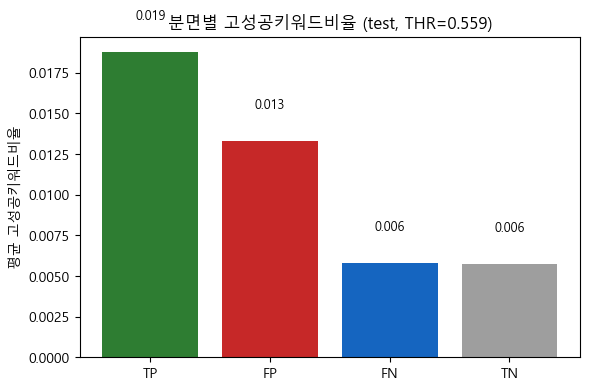

분면별 고성공키워드비율: {'TP': 0.019, 'FP': 0.013, 'FN': 0.006, 'TN': 0.006}


In [5]:
# [E] FN·FP 연결: 분면별 고성공키워드비율 (test, v2 예측)
from sklearn.metrics import f1_score
sc=pd.read_parquet(EXP/'learned_product_scores.parquet'); sc['cd']=sc['ITEM_CD'].map(norm_id)
pm=dict(zip(sc['cd'],sc['pred_success_prob'])); prob=np.array([pm.get(p,np.nan) for p in pids])
def f1max(yv,pv):
    best=(0,0.5)
    for t in np.unique(pv):
        f=f1_score(yv,(pv>=t).astype(int),zero_division=0)
        if f>best[0]: best=(f,t)
    return best[1]
THR=f1max(y_np[va],prob[va]); pred=(prob>=THR).astype(int)
quad=np.where((pred==1)&(y_np==1),'TP',np.where((pred==1)&(y_np==0),'FP',np.where((pred==0)&(y_np==1),'FN','TN')))
kw_by_prod=pk.groupby('pid')['keyword'].apply(list)
def hsr(p):
    L=[str(x) for x in kw_by_prod.get(p,[])]; return float(np.mean([x in kw_succ for x in L])) if L else 0.0
hsr_arr=np.array([hsr(p) for p in pids])
qd=pd.DataFrame({'quad':quad[te],'hsr':hsr_arr[te]}); quad_tbl=qd.groupby('quad')['hsr'].mean().reindex(['TP','FP','FN','TN'])
fig,ax=plt.subplots(figsize=(6,4)); qc={'TP':'#2e7d32','FP':'#c62828','FN':'#1565c0','TN':'#9e9e9e'}
ax.bar(quad_tbl.index,quad_tbl.values,color=[qc[q] for q in quad_tbl.index])
for i,v in enumerate(quad_tbl.values): ax.text(i,v+0.002,f'{v:.3f}',ha='center',fontsize=9)
ax.set_ylabel('평균 고성공키워드비율'); ax.set_title(f'분면별 고성공키워드비율 (test, THR={THR:.3f})')
plt.tight_layout(); savefig(fig,'kwgen_quad.png'); plt.show()
print('분면별 고성공키워드비율:', {k:round(float(v),3) for k,v in quad_tbl.items()})

In [6]:
# [보고서] keyword_generality_report.md 생성
rarer = med_s < med_all
ans = '아니다 — **고성공키워드는 오히려 희귀·특이한 키워드**다' if rarer else '그렇다 — 고성공키워드가 더 흔한 편이다'
def _kex(df): return ', '.join(f"{k}({r['mean']:.2f}/{int(r['pop'])})" for k,r in df.iterrows())
top_common=ko.sort_values('pop',ascending=False).head(8)
def _kvs(df,col,fmt): return ', '.join(f'{k}({fmt.format(v)})' for k,v in df[col].items())
L=[]; A=L.append
A('# 키워드 일반성 분석 — 고성공키워드는 \'흔한\' 키워드인가?\n')
A('> v2_sweepA · train+val 라벨만 · 노트북 `keyword_generality.ipynb` Run All 자동 생성.\n')
A('## 0. 분석 개요\n')
A('**소목적**: 고성공키워드(성공률 상위 5%)가 여러 상품에 두루 쓰이는 *흔한* 키워드인지, 소수 상품에만 붙는 *희귀·특이* 키워드인지 규명.\n')
A('**상위목적과의 연결**: 모델은 유사상품(공유키워드/IP)으로 성패를 가른다(`network_eda_report.md` M0·M3). 그렇다면 "성공을 끌어올리는 키워드"의 성격을 알면 **FN(놓친 성공)·FP(낚인 실패)** 가 왜 생기는지 더 깊이 설명된다.\n')
A(f'**정의(재사용)**: 키워드 성공률 = (train+val에서 그 키워드 보유 상품 중 성공 비율), 등장상품수≥{MIN}만 분석. 고성공=성공률 상위5%(≥{hi:.2f}, {len(kw_succ)}개)·고실패=하위5%(≤{lo:.2f}, {len(kw_fail)}개). 일반성=등장 상품수. 기저성공률={base:.3f}.\n')
A('## A·B. 성공률 vs 일반성 (산점도)\n')
A('### 🔬 분석/그림\n')
A(f'Spearman(일반성,성공률)=**{sp:.3f}**, Pearson(log10 일반성,성공률)=**{pr:.3f}**.\n')
A('![성공률 vs 일반성](report_assets/kwgen_scatter.png)\n')
A(f'**📌 볼 점** — 흔한 키워드(오른쪽)일수록 성공률이 기저({base:.2f}) 근처로 수렴하고, **고성공(빨강)·고실패(파랑) 극단값은 왼쪽(희귀 영역)에 몰린다**. 흔한 키워드는 거의 모든 상품에 붙어 성공/실패를 가르지 못한다. 단 우측 끝의 **`콜라보`(등장상품수 80·성공률 0.64, 보라 원)**는 예외 — 흔하면서도 고성공인 *협업 전략 신호*다.\n')
A('## C. 일반성 분포 — 고성공 vs 고실패 vs 전체\n')
A('![일반성 분포](report_assets/kwgen_box.png)\n')
A(f'**📌 볼 점** — 등장상품수 중앙값: 전체 **{med_all:.0f}**, 고성공 **{med_s:.0f}**, 고실패 **{med_f:.0f}**. 고성공 키워드 중앙값이 전체보다 {"낮다(더 희귀)" if rarer else "높다(더 흔함)"}.\n')
A('## D. 일반성 구간별 평균 성공률\n')
A('![구간별 성공률](report_assets/kwgen_bin.png)\n')
A(f'**📌 볼 점** — 가장 희귀한 구간 평균성공률 {binmin:.3f}(편차 {stdmin:.3f}) vs 가장 흔한 구간 {binmax:.3f}(편차 {stdmax:.3f}). **흔할수록 성공률이 기저로 수렴하고 편차가 줄어든다** = 흔한 키워드엔 성패 신호가 거의 없다.\n')
A('## E. FN·FP 연결 — 분면별 고성공키워드비율\n')
A('![분면별 고성공키워드비율](report_assets/kwgen_quad.png)\n')
A(f'**📌 볼 점** — 분면별 평균 고성공키워드비율: TP {quad_tbl["TP"]:.3f} / FP {quad_tbl["FP"]:.3f} / FN {quad_tbl["FN"]:.3f} / TN {quad_tbl["TN"]:.3f}. 절대값이 모두 작은 이유는 고성공 키워드가 **희귀**해 한 상품이 가질 확률 자체가 낮기 때문. 그래도 예측성공(TP·FP)이 예측실패(FN·TN)보다 높다.\n')
A('## 종합 — 소목적 답 · FN/FP 함의\n')
A(f'- **소목적 답**: {ans}. 흔한 키워드(간식·달콤 등)는 성공률이 기저로 수렴해 변별력이 없고, 성패를 가르는 고성공 키워드는 소수 상품에만 붙는 **특이 신호**다.\n')
A('- **모델 학습 해석**: 모델이 성공을 끌어올리는 힘은 "흔한 키워드를 많이 가졌나"가 아니라 "**드물지만 성공과 강하게 결부된 특이 키워드/유사 성공작과의 연결**"에서 나온다(M0 α_r의 sim_kw·sim_ip 우위와 정합).\n')
A('- **FN(놓친 성공)**: 고성공키워드비율이 가장 낮다 → 신규·이질 성공작은 *특이 성공 키워드가 없어* 평범해 보여 모델이 못 끌어올린다.\n')
A('- **FP(낚인 실패)**: 고성공 키워드 보유는 TP보다 약하지만, 유사상품·트렌드 외형으로 점수가 올라가 과대평가된다(M1~M3와 일관).\n')
A(f'- **고성공 키워드 {len(kw_succ)}개 · 보유 상품 {n_prod_succ}개 — 예시 20(성공률/보유상품수)**: {_kex(ex_s)}.\n')
A(f'- **고실패 키워드 {len(kw_fail)}개 · 보유 상품 {n_prod_fail}개 — 예시 20(성공률/보유상품수)**: {_kex(ex_f)}.\n')
A(f'- **참고 · 가장 흔한 키워드(등장상품수)**: {_kvs(top_common,"pop","{:.0f}")} → 대부분 성공률이 기저 부근.\n')
A(f'- **IP 포함 여부**: 이 분석의 키워드는 keyword 노드(상품 키워드)로 **IP 노드와 별개**다. 키워드 vocab 1923개 중 IP명과 겹치는 건 11개(0.6%)뿐 — 고성공∩IP={ip_in_succ}, 고실패∩IP={ip_in_fail}.\n')
A('- **한계**: train+val 기준 집계(소표본 키워드 분산 큼)·상관≠인과·등장상품수≥{} 컷오프 의존.'.format(MIN))
open(NBDIR/'keyword_generality_report.md','w',encoding='utf-8').write('\n'.join(L))
print('생성: keyword_generality_report.md | 그림 kwgen_*.png 4종')

생성: keyword_generality_report.md | 그림 kwgen_*.png 4종
